In [1]:
!pip install -q tensorflow
!pip install -q scikit-learn pandas matplotlib

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

print("TensorFlow version:", tf.__version__)

from google.colab import files
uploaded = files.upload() 
csv_filename = list(uploaded.keys())[0]
print("Loaded:", csv_filename)


TensorFlow version: 2.19.0


Saving 0000.csv to 0000.csv
Loaded: 0000.csv


In [ ]:
df = pd.read_csv(csv_filename)
print(df.shape)
print(df.columns)
df.head()

(32399, 12)
Index(['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG',
       'AIRFLOW', 'THOR RES', 'ABDO RES', 'sample_index'],
      dtype='object')


,SaO2,PR,EEG(sec),ECG,EMG,EOG(L),EOG(R),EEG,AIRFLOW,THOR RES,ABDO RES,sample_index
0,96.011160,67.264629,0.980392,-0.266667,-0.000000,-38.235294,29.411765,-11.764706,-3.984314,1.568627,0.282353,0
1,96.011160,67.264629,3.921569,-0.211765,-1.458825,-17.647059,17.647059,-2.941176,-3.984314,1.286275,-0.658824,1
2,96.011160,69.262709,2.941176,-0.250980,-0.000000,14.705882,9.803922,2.941176,-3.984314,-0.533333,-3.764706,2
3,96.011160,72.259828,-0.000000,-0.203922,0.729412,-23.529412,9.803922,-5.882353,-2.070588,2.478431,0.501961,3
4,97.010197,78.241885,-7.843137,-0.227451,-0.000000,40.196078,-29.411765,6.862745,-0.062745,3.356863,2.415686,4


In [ ]:
# Feature Selection
if 'sample_index' in df.columns:
    df = df.drop(columns=['sample_index'])

df = df.select_dtypes(include=[np.number]).copy()
print("Using features:", df.columns.tolist())

df = df.interpolate().fillna(method='bfill').fillna(method='ffill')  # simple cleaning

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.values)  


Using features: ['SaO2', 'PR', 'EEG(sec)', 'ECG', 'EMG', 'EOG(L)', 'EOG(R)', 'EEG', 'AIRFLOW', 'THOR RES', 'ABDO RES']


/tmp/ipython-input-2472078337.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.interpolate().fillna(method='bfill').fillna(method='ffill')  # simple cleaning


In [ ]:

def create_windows(X, seq_len=100, step=1):
    n_samples, n_features = X.shape
    windows = []
    idxs = []
    for start in range(0, n_samples - seq_len + 1, step):
        windows.append(X[start:start+seq_len])
        idxs.append(start + seq_len - 1) 
    return np.stack(windows), np.array(idxs)

SEQ_LEN = 100 
STEP = 1
X_windows, window_end_idxs = create_windows(X_scaled, seq_len=SEQ_LEN, step=STEP)
print("Windows shape:", X_windows.shape)  

Windows shape: (32300, 100, 11)


In [ ]:

train_windows, val_windows = train_test_split(X_windows, test_size=0.1, random_state=42)
print("Train shape:", train_windows.shape, "Val shape:", val_windows.shape)


Train shape: (29070, 100, 11) Val shape: (3230, 100, 11)


In [ ]:

n_features = X_windows.shape[2]
latent_dim = 16
tf.keras.backend.clear_session()

inputs = layers.Input(shape=(SEQ_LEN, n_features))
# Encoder
x = layers.LSTM(64, return_sequences=True)(inputs)
x = layers.LSTM(32, return_sequences=False)(x)
encoded = layers.Dense(latent_dim, activation='relu')(x)

# Decoder
x = layers.RepeatVector(SEQ_LEN)(encoded)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.LSTM(64, return_sequences=True)(x)
decoded = layers.TimeDistributed(layers.Dense(n_features))(x)

autoencoder = models.Model(inputs, decoded)
autoencoder.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 11)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 64)        │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 100, 11)        │           715 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,219 (250.86 KB)

 Trainable params: 64,219 (250.86 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training
EPOCHS = 40
BATCH_SIZE = 128
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)

history = autoencoder.fit(
    train_windows, train_windows,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(val_windows, val_windows),
    callbacks=[es],
    verbose=2
)


Epoch 1/40
228/228 - 15s - 68ms/step - loss: 0.9339 - val_loss: 0.8823
Epoch 2/40
228/228 - 6s - 26ms/step - loss: 0.9197 - val_loss: 0.8798
Epoch 3/40
228/228 - 6s - 27ms/step - loss: 0.9186 - val_loss: 0.8782
Epoch 4/40
228/228 - 6s - 29ms/step - loss: 0.9165 - val_loss: 0.8754
Epoch 5/40
228/228 - 6s - 28ms/step - loss: 0.9134 - val_loss: 0.8716
Epoch 6/40
228/228 - 6s - 26ms/step - loss: 0.9074 - val_loss: 0.8666
Epoch 7/40
228/228 - 7s - 30ms/step - loss: 0.9032 - val_loss: 0.8651
Epoch 8/40
228/228 - 6s - 26ms/step - loss: 0.9018 - val_loss: 0.8619
Epoch 9/40
228/228 - 6s - 28ms/step - loss: 0.8994 - val_loss: 0.8560
Epoch 10/40
228/228 - 6s - 26ms/step - loss: 0.8952 - val_loss: 0.8583
Epoch 11/40
228/228 - 7s - 29ms/step - loss: 0.8953 - val_loss: 0.8533
Epoch 12/40
228/228 - 6s - 27ms/step - loss: 0.8916 - val_loss: 0.8473
Epoch 13/40
228/228 - 6s - 28ms/step - loss: 0.8874 - val_loss: 0.8475
Epoch 14/40
228/228 - 6s - 28ms/step - loss: 0.8906 - val_loss: 0.8572
Epoch 15/40
22

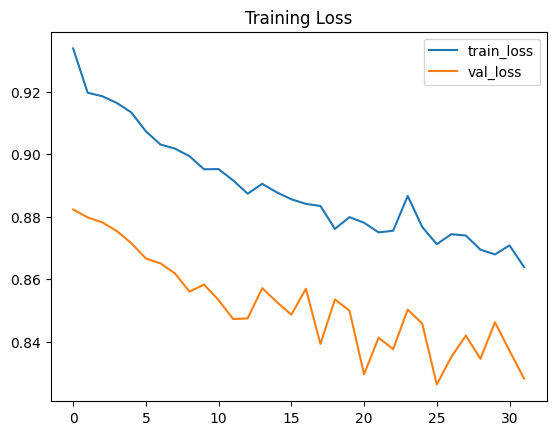

In [ ]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Training Loss"); plt.show()

In [ ]:
# Reconstruction error on all windows
reconstructions = autoencoder.predict(X_windows)
mse_per_window = np.mean(np.square(reconstructions - X_windows), axis=(1,2))  # MSE per window


1010/1010 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step


In [ ]:
# threshold selection
# Option A: statistical: mean + k*std
k = 3.0
mu = mse_per_window.mean()
sigma = mse_per_window.std()
threshold_stat = mu + k * sigma

# Option B: percentile (e.g., top 2% as anomalies)
percentile = 98
threshold_pct = np.percentile(mse_per_window, percentile)

print("MSE mean:", mu, "std:", sigma)
print("Threshold (mean+k*std):", threshold_stat)
print(f"Threshold (percentile {percentile}):", threshold_pct)

threshold = threshold_pct

MSE mean: 0.8606484707576165 std: 1.4759812540568749
Threshold (mean+k*std): 5.288592232928241
Threshold (percentile 98): 6.590326951135771


In [ ]:
# Detect anomalies: windows where mse > threshold
anomaly_mask_windows = mse_per_window > threshold
print("Number of anomalous windows:", anomaly_mask_windows.sum(), "out of", len(mse_per_window))

Number of anomalous windows: 646 out of 32300


In [ ]:
# Mark a sample as anomalous if it is included in any anomalous window
n_samples = X_scaled.shape[0]
sample_anomaly = np.zeros(n_samples, dtype=bool)

for i, is_anom in enumerate(anomaly_mask_windows):
    if is_anom:
        start_idx = i  
        sample_anomaly[start_idx:start_idx+SEQ_LEN] = True

pct_samples_anomalous = sample_anomaly.sum() / len(sample_anomaly) * 100
print(f"Percent of samples flagged anomalous: {pct_samples_anomalous:.2f}%")

Percent of samples flagged anomalous: 3.62%


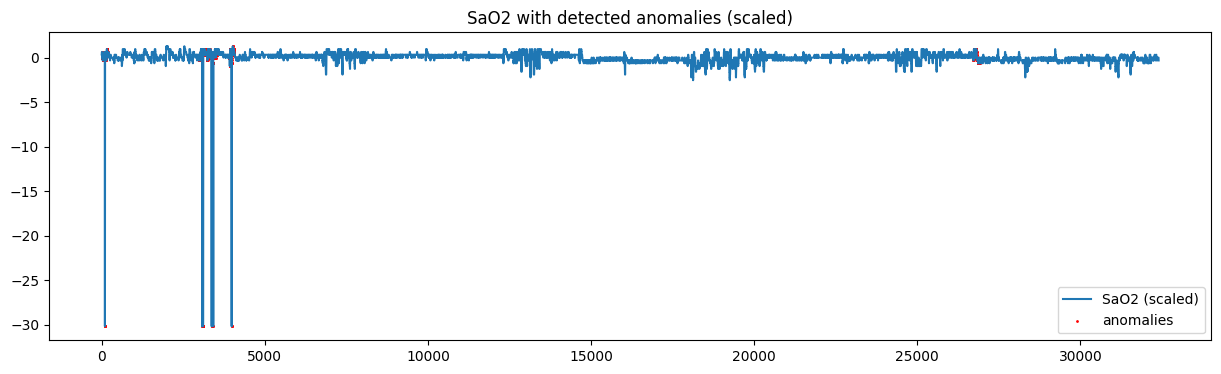

In [ ]:
time = np.arange(n_samples)
feature_to_plot = 0 
feature_name = df.columns[feature_to_plot]

plt.figure(figsize=(15,4))
plt.plot(time, X_scaled[:, feature_to_plot], label=f"{feature_name} (scaled)")
anom_idxs = np.where(sample_anomaly)[0]
plt.scatter(anom_idxs, X_scaled[anom_idxs, feature_to_plot], color='red', s=1, label='anomalies')
plt.legend()
plt.title(f"{feature_name} with detected anomalies (scaled)")
plt.show()


In [ ]:
top_k = 10
top_idx = np.argsort(mse_per_window)[-top_k:][::-1]
for rank, idx in enumerate(top_idx, 1):
    print(f"Rank {rank}: window_idx={idx}, mse={mse_per_window[idx]:.6f}, window_end_sample={window_end_idxs[idx]}")

Rank 1: window_idx=3027, mse=15.815199, window_end_sample=3126
Rank 2: window_idx=3028, mse=15.428495, window_end_sample=3127
Rank 3: window_idx=3327, mse=14.198664, window_end_sample=3426
Rank 4: window_idx=3329, mse=14.179204, window_end_sample=3428
Rank 5: window_idx=3326, mse=14.165686, window_end_sample=3425
Rank 6: window_idx=3328, mse=14.163273, window_end_sample=3427
Rank 7: window_idx=3026, mse=14.160471, window_end_sample=3125
Rank 8: window_idx=3330, mse=14.143326, window_end_sample=3429
Rank 9: window_idx=3324, mse=14.104644, window_end_sample=3423
Rank 10: window_idx=3323, mse=14.096925, window_end_sample=3422


'\nfrom sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix\ny_true = labels  # shape (n_samples,)\ny_pred = sample_anomaly.astype(int)\nprecision = precision_score(y_true, y_pred)\nrecall = recall_score(y_true, y_pred)\nf1 = f1_score(y_true, y_pred)\nroc = roc_auc_score(y_true, mse_per_window_mapped_if_needed)  # careful: ROC often uses continuous score\nprint("Precision, Recall, F1:", precision, recall, f1)'

In [ ]:
results_df = pd.DataFrame({
    'sample_index': np.arange(n_samples),
    'is_anomaly': sample_anomaly.astype(int)
})
results_df.to_csv("anomaly_results_by_sample.csv", index=False)
from google.colab import files
files.download("anomaly_results_by_sample.csv")
print("Saved anomaly_results_by_sample.csv and provided download link.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved anomaly_results_by_sample.csv and provided download link.


In [ ]:
autoencoder.save("lstm_autoencoder_model.h5")

print("Model saved successfully!")

✅ Model saved successfully!
